    Author(s): Daniel Tweneboah Anyimadu

INFERENCE

(01) Configure Paths
  - "ts_dir" (testing data directory - ensure it contains "HR" & "LR" folders with matching data pairs)

(02) Feel free to execute the code as it is. 

NB: Data dimensions must follow HR = 2 × LR (e.g., HR: 512×512 corresponds to LR: 256×256).

# Connecting Google Colab (Jupyter Notebook) & Google Drive:

To access the dataset.

In [67]:
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

In [ ]:
# T1w configuration
ts_dir =  "G:\\LF-7T-CycleGAN\\pytorch-cyclegan-and-pix2pix\\results\\SRDDL-evaluation-dataset\\T1w"
checkpoint_path = "G:\\LF-7T-CycleGAN\\benchmarks\\SRDDL\\weight\\checkpoints-full-dataset-run.pt"

# T2w configuration
ts_dir =  "G:\\LF-7T-CycleGAN\\pytorch-cyclegan-and-pix2pix\\results\\SRDDL-evaluation-dataset\\T2w"
checkpoint_path = "G:\\LF-7T-CycleGAN\\benchmarks\\SRDDL\\weight\\T2w-checkpoints-full-dataset-run.pt"

# **INSTALL PACKAGES & IMPORT LIBRARIES**

In [69]:
# Install packages
!pip install pillow matplotlib tqdm kornia scikit-image scipy lpips patchify torch torchvision      

In [70]:
from __future__ import annotations

# Libraries for exploratory data analysis (EDA)
%matplotlib inline
import os
import cv2
from pathlib import Path
import random
import numpy as np
import pandas as pd
import seaborn as sns
from glob import glob
from tqdm import tqdm
from PIL import Image
from pathlib import Path
from scipy.io import loadmat
import matplotlib.pyplot as plt
from IPython.display import clear_output
from typing import List, Optional, Tuple

# Libraries for data preprocessing/preparation
from einops import rearrange
from scipy.ndimage import zoom
import kornia.augmentation as K
from dataclasses import dataclass
from numpy.fft import fft2, fftshift
from patchify import patchify, unpatchify
from einops.layers.torch import Rearrange
from scipy.fftpack import fftshift, ifftshift, ifftn, fftn
from sklearn.model_selection import KFold, train_test_split

# Libraries for AI model setup: PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, Subset

# Evalution metrics
import gc
import math
import lpips
import scipy.stats as stats
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim, mean_squared_error as mse

# Filter warnings
import warnings
warnings.filterwarnings("ignore")

___________________

# **(A): EXPLORATORY DATA ANALYSIS (EDA)**

# Testing Dataset

In [71]:
# Define file paths for HR and LR dataset
HRdir = os.path.join(ts_dir, "HR")
LRdir = os.path.join(ts_dir, "LR")

# List files and sort them
HRfile = sorted([os.path.join(HRdir, file) for file in tqdm(os.listdir(HRdir)) if file.endswith(".npy")]) # [10:11] #[:10] 
LRfile = sorted([os.path.join(LRdir, file) for file in tqdm(os.listdir(LRdir)) if file.endswith(".npy")]) # [10:11] #[:10]

# Create & display DataFrame
ts_df = pd.DataFrame({"gdtFiles": HRfile,"imgFiles": LRfile})
ts_df.head()

100%|██████████| 370/370 [00:00<00:00, 85815.78it/s]


,gdtFiles,imgFiles
0,G:\LF-7T-CycleGAN\pytorch-cyclegan-and-pix2pix...,G:\LF-7T-CycleGAN\pytorch-cyclegan-and-pix2pix...
1,G:\LF-7T-CycleGAN\pytorch-cyclegan-and-pix2pix...,G:\LF-7T-CycleGAN\pytorch-cyclegan-and-pix2pix...
2,G:\LF-7T-CycleGAN\pytorch-cyclegan-and-pix2pix...,G:\LF-7T-CycleGAN\pytorch-cyclegan-and-pix2pix...
3,G:\LF-7T-CycleGAN\pytorch-cyclegan-and-pix2pix...,G:\LF-7T-CycleGAN\pytorch-cyclegan-and-pix2pix...
4,G:\LF-7T-CycleGAN\pytorch-cyclegan-and-pix2pix...,G:\LF-7T-CycleGAN\pytorch-cyclegan-and-pix2pix...


Plot Visualizations

imgTs Shape: (128, 128) || imgTs maxVal: 0.9899799823760986 || imgTs minVal: -0.9379256963729858
gdtTs Shape: (256, 256) || gdtTs maxVal: 1.1164984703063965 || gdtTs minVal: -1.0782395601272583


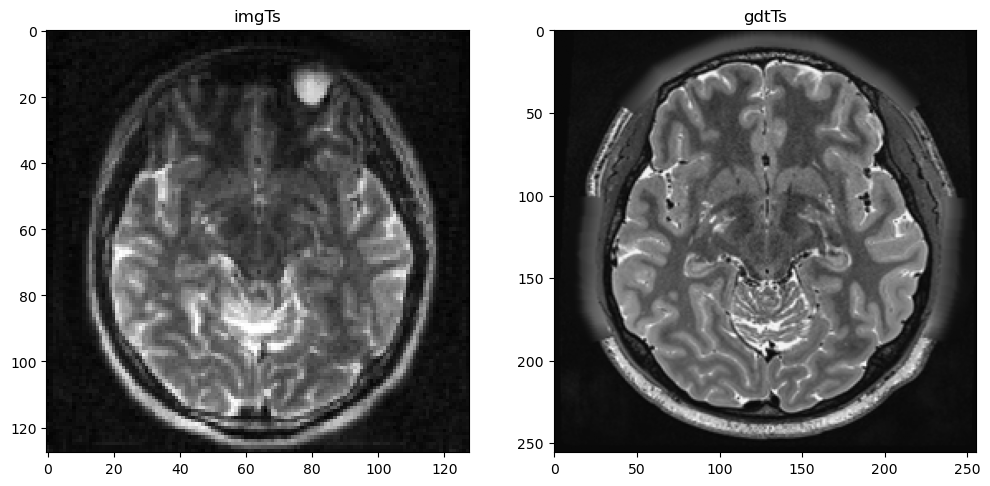

In [72]:
# Load the imgFiles, and gdtFiles
imgTs = np.load(ts_df["imgFiles"].iloc[0])
gdtTs = np.load(ts_df["gdtFiles"].iloc[0])

print(f"imgTs Shape: {imgTs.shape} || imgTs maxVal: {imgTs.max()} || imgTs minVal: {imgTs.min()}")
print(f"gdtTs Shape: {gdtTs.shape} || gdtTs maxVal: {gdtTs.max()} || gdtTs minVal: {gdtTs.min()}")

# Plot the imgTs, and gdtTs side by side 
plt.figure(figsize=[12, 6])
plt.subplot(1, 2, 1); plt.imshow(imgTs, cmap='gray'); plt.title(f"imgTs") 
plt.subplot(1, 2, 2); plt.imshow(gdtTs, cmap='gray'); plt.title(f"gdtTs") 
plt.show()

___________________

# **(B): DATA PREPROCESSING/PREPARATION**

# Patch Extraction, Patch Reconstruction, & Scaling (On Training Dataset)

Functions for Patch Extraction, Patch Reconstruction, & Scaling

In [73]:
# Function to extract 2D patches from a slice
def patch(data, patch_size=(32, 32), step=16):
    """ Extracts patches from a 2D data. """
    patches = patchify(data, patch_size, step=step)
    return patches

# Function to reconstruct the full data from 2D patches
def unpatch(patches, data_shape):
    """ Reconstructs the 2D data from extracted patches. """
    reconstructed = unpatchify(patches, data_shape)
    return reconstructed

# Function to extract paired 2D patches
scale = 2; lr_patch_size = (32, 32); lr_step = 16
def pairedPatch(hr_img, lr_img, scale=scale, lr_patch_size=lr_patch_size, lr_step=lr_step):
    """Extract aligned LR/HR patches for super-resolution."""
    lr_ph, lr_pw = lr_patch_size
    hr_patch_size = (lr_ph * scale, lr_pw * scale)
    hr_step = lr_step * scale

    assert hr_img.shape[0] == lr_img.shape[0] * scale, f"H mismatch: {hr_img.shape} vs {lr_img.shape}"
    assert hr_img.shape[1] == lr_img.shape[1] * scale, f"W mismatch: {hr_img.shape} vs {lr_img.shape}"

    lr_patches = patch(lr_img, patch_size=lr_patch_size, step=lr_step)
    hr_patches = patch(hr_img, patch_size=hr_patch_size, step=hr_step)

    assert lr_patches.shape[:2] == hr_patches.shape[:2]
    return hr_patches, lr_patches

# Augmentations

In [74]:
# Horizontal Flip
def hFlip(image, target, prob=0.5):
    if random.random() < prob:
        image  = torch.flip(image, dims=[2])  # horizontal (W axis)
        target = torch.flip(target, dims=[2]) # horizontal (W axis)
    return image, target

# 90-degree rotation
def rot90(image, target, prob=0.5):
    if random.random() < prob:
        k = random.randint(0, 3)  # 0,1,2,3 → 0°,90°,180°,270°
        image  = torch.rot90(image, k, dims=[1, 2])
        target = torch.rot90(target, k, dims=[1, 2])
    return image, target

# Create Customized DataLoader

Define PyTorch Dataset

In [75]:
# Define Custom Dataset to Ensure Inputs & Targets are Paired
class ImagesDataset(Dataset):
    def __init__(self, X, y, hflip_prob=0.0, rot_prob=0.0):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.hflip_prob = hflip_prob
        self.rot_prob   = rot_prob

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image  = self.X[idx]  # (C, H, W)
        target = self.y[idx]  # (C, H, W)

        # Apply augmentations if enabled
        if self.hflip_prob > 0.0:
            image, target = hFlip(image, target, self.hflip_prob)

        if self.rot_prob > 0.0:
            image, target = rot90(image, target, self.rot_prob)

        return image, target # Returns (input, target)

___________________

# (C): AI MODEL SETUP - PyTorch FRAMEWORK

**Dictionary Building Block**

In [76]:
class PatchConv(nn.Module):
    def __init__(self, channels: int, tanh: bool = False):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(channels, channels, 1, 1, 0),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 1, 1, 0),
        )
        self.act = nn.Tanh() if tanh else nn.ReLU(inplace=True)

    def forward(self, x):
        return self.act(self.body(x))

**HR Dictionary Generator**

In [77]:
class Dictionary(nn.Module):
    """
    Generates an explicit HR dictionary from random noise.
    Output atoms have spatial size (scale x scale).
    """
    def __init__(self, n_atoms: int, patch_size: int):
        super().__init__()
        assert math.log2(n_atoms).is_integer(), "n_atoms must be a power of 2"

        self.depth = int(math.log2(n_atoms))
        self.patch_size = patch_size

        for k in range(self.depth):
            for i in range(2 ** (k + 1)):
                setattr(
                    self,
                    f"conv_{k + 1}_{i + 1}",
                    PatchConv(patch_size ** 2, tanh=(k == self.depth - 1))
                )

        self.pixel_shuffle = nn.PixelShuffle(patch_size)

        self.code = nn.Sequential(
            nn.Conv2d(n_atoms, n_atoms, patch_size, patch_size, 0, groups=n_atoms),
            nn.ReLU(inplace=True),
            nn.Conv2d(n_atoms, n_atoms, 1, 1, 0),
        )

    def forward(self, x, shuffle=False):
        atoms = [x]

        for k in range(self.depth):
            new_atoms = [None] * (len(atoms) * 2)
            for i in range(len(atoms)):
                left = getattr(self, f"conv_{k + 1}_{i * 2 + 1}")(atoms[i])
                right = getattr(self, f"conv_{k + 1}_{i * 2 + 2}")(atoms[i])

                if k == self.depth - 1:
                    left = self.pixel_shuffle(left)
                    right = self.pixel_shuffle(right)

                new_atoms[i * 2] = left
                new_atoms[i * 2 + 1] = right

            atoms = new_atoms

        if shuffle:
            import random
            random.shuffle(atoms)

        d = torch.cat(atoms, dim=1)   # [B, N, s, s]
        c = self.code(d)              # [B, N, 1, 1]
        return d, c

**Bottleneck Residual Blocks**

In [78]:
class Bottleneck(nn.Module):
    def __init__(self, nf: int):
        super().__init__()
        mid = max(nf // 4, 1)
        self.block = nn.Sequential(
            nn.Conv2d(nf, mid, 1, 1, 0),
            nn.BatchNorm2d(mid),
            nn.ReLU(inplace=True),

            nn.Conv2d(mid, mid, 3, 1, 1),
            nn.BatchNorm2d(mid),
            nn.ReLU(inplace=True),

            nn.Conv2d(mid, nf, 1, 1, 0),
            nn.BatchNorm2d(nf),
        )

    def forward(self, x):
        return x + self.block(x)


class BottleneckGroup(nn.Module):
    def __init__(self, nf: int, n_blocks: int):
        super().__init__()
        layers = [Bottleneck(nf) for _ in range(n_blocks)]
        layers.append(nn.Conv2d(nf, nf, 1, 1, 0))
        self.group = nn.Sequential(*layers)

    def forward(self, x):
        return x + self.group(x)

**Reduced UNet++ Blocks**

In [79]:
class ConvBlock(nn.Module):
    def __init__(self, in_c: int, mid_c: int, out_c: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, mid_c, 3, 1, 1),
            nn.BatchNorm2d(mid_c),
            nn.ReLU(inplace=True),

            nn.Conv2d(mid_c, out_c, 3, 1, 1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

**Nested UNet Feature Extractor**

In [80]:
class NestedUNet(nn.Module):
    def __init__(self, nfs, in_channels=1):
        super().__init__()
        self.pool = nn.MaxPool2d(2, 2)
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)

        self.initial = nn.Conv2d(in_channels, nfs[0] // 2, 3, 1, 1)

        self.conv0_0 = ConvBlock(in_channels, nfs[0], nfs[0])
        self.conv1_0 = ConvBlock(nfs[0], nfs[1], nfs[1])
        self.conv2_0 = ConvBlock(nfs[1], nfs[2], nfs[2])
        self.conv3_0 = ConvBlock(nfs[2], nfs[3], nfs[3])

        self.conv0_1 = ConvBlock(nfs[0] + nfs[1], nfs[0], nfs[0])
        self.conv1_1 = ConvBlock(nfs[1] + nfs[2], nfs[1], nfs[1])
        self.conv2_1 = ConvBlock(nfs[2] + nfs[3], nfs[2], nfs[2])

        self.conv0_2 = ConvBlock(nfs[0] * 2 + nfs[1], nfs[0], nfs[0])
        self.conv1_2 = ConvBlock(nfs[1] * 2 + nfs[2], nfs[1], nfs[1])

        self.conv0_3 = ConvBlock(nfs[0] * 3 + nfs[1], nfs[0], nfs[0])

        self.final = nn.Conv2d(nfs[0] + nfs[0] // 2, nfs[0], 3, 1, 1)

    def forward(self, x):
        xini = self.initial(x)

        x0_0 = self.conv0_0(x)
        x1_0 = self.conv1_0(self.pool(x0_0))
        x0_1 = self.conv0_1(torch.cat([x0_0, self.up(x1_0)], dim=1))

        x2_0 = self.conv2_0(self.pool(x1_0))
        x1_1 = self.conv1_1(torch.cat([x1_0, self.up(x2_0)], dim=1))
        x0_2 = self.conv0_2(torch.cat([x0_0, x0_1, self.up(x1_1)], dim=1))

        x3_0 = self.conv3_0(self.pool(x2_0))
        x2_1 = self.conv2_1(torch.cat([x2_0, self.up(x3_0)], dim=1))
        x1_2 = self.conv1_2(torch.cat([x1_0, x1_1, self.up(x2_1)], dim=1))
        x0_3 = self.conv0_3(torch.cat([x0_0, x0_1, x0_2, self.up(x1_2)], dim=1))

        return self.final(torch.cat([x0_3, xini], dim=1))

**Single-channel MRI SRDD Model**

In [81]:
class MRI_SRDD(nn.Module):
    def __init__(self, scale=2, n_atoms=64, in_channels=1):
        super().__init__()
        self.scale = scale
        self.n_atoms = n_atoms

        nfs = [n_atoms, n_atoms * 2, n_atoms * 4, n_atoms * 8]

        self.dict_gen = Dictionary(n_atoms=n_atoms, patch_size=scale)
        self.body = NestedUNet(nfs=nfs, in_channels=in_channels)

        self.tail = nn.Sequential(
            nn.Conv2d(nfs[0] + n_atoms, nfs[0] + n_atoms, 1, 1, 0),
            BottleneckGroup(nfs[0] + n_atoms, n_blocks=10),
            nn.Conv2d(nfs[0] + n_atoms, n_atoms, 1, 1, 0),
            nn.Softmax(dim=1),
        )

        self.comp = nn.Sequential(
            nn.Conv2d(n_atoms, n_atoms, 2, 1, 0),
            nn.ReLU(inplace=True),
            nn.Conv2d(n_atoms, n_atoms, 1, 1, 0),
            nn.Softmax(dim=1),
        )

        self.fuse = nn.Conv2d(2, 1, 5, 1, 0)

    def forward(self, x, stored_dict=None, stored_code=None, shuffle=False):
        """
        x: [B, 1, H, W]
        output: [B, 1, scale*H, scale*W]
        """
        b, _, h, w = x.shape

        # Base upsample branch
        x_base = F.interpolate(x, scale_factor=self.scale, mode="bicubic", align_corners=False)

        # Dictionary
        if stored_dict is None or stored_code is None:
            z = torch.randn(b, self.scale ** 2, 1, 1, device=x.device)
            d, c = self.dict_gen(z, shuffle=shuffle)   # d: [B,N,s,s], c:[B,N,1,1]
            d = d.repeat(1, 1, h, w)                   # [B,N,sH,sW] after spatial repeat
            c = c.repeat(1, 1, h, w)                   # [B,N,H,W]
        else:
            d, c = stored_dict, stored_code

        # Feature extraction + coefficient prediction
        feat = self.body(x)                            # [B,n_atoms,H,W]
        pred = self.tail(torch.cat([feat, c], dim=1)) # [B,N,H,W]
        comp = self.comp(pred)                         # [B,N,H-1,W-1] effectively after conv2d k=2

        # Upsample coefficient maps
        pred_up = F.interpolate(pred, scale_factor=self.scale, mode="nearest")
        comp_up = F.interpolate(comp, scale_factor=self.scale, mode="nearest")

        # Main reconstruction
        x_main = torch.sum(pred_up * d, dim=1, keepdim=True)

        # Complementary reconstruction
        y_comp = torch.sum(comp_up * d[:, :, self.scale:, self.scale:], dim=1, keepdim=True)

        # Boundary compensation
        m = self.scale // 2
        if x_main.shape[-1] > 2 * (m + 2) + 4 and x_main.shape[-2] > 2 * (m + 2) + 4:
            fused = self.fuse(torch.cat([x_main[:, :, m:-m, m:-m], y_comp], dim=1))
            x_main[:, :, m + 2:-m - 2, m + 2:-m - 2] = fused

        # Residual add
        out = x_main + x_base

        atom_vis = d[:1, :, :self.scale, :self.scale]
        code_vis = c[:1, :, :1, :1]

        return out, atom_vis, code_vis

**SRDDL Architecture**

**Spatial**

In [82]:
# Assuming 'model' is your built PyTorch model
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using {device} device")
model = MRI_SRDD(scale=2, n_atoms=64, in_channels=1).to(device)
print(model) # Print the model architecture

# Calculate the total number of parameters
num_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {num_params}")

for name, param in model.named_parameters():
    print(name, param.numel())

Using cuda device
MRI_SRDD(
  (dict_gen): Dictionary(
    (conv_1_1): PatchConv(
      (body): Sequential(
        (0): Conv2d(4, 4, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(4, 4, kernel_size=(1, 1), stride=(1, 1))
      )
      (act): ReLU(inplace=True)
    )
    (conv_1_2): PatchConv(
      (body): Sequential(
        (0): Conv2d(4, 4, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(4, 4, kernel_size=(1, 1), stride=(1, 1))
      )
      (act): ReLU(inplace=True)
    )
    (conv_2_1): PatchConv(
      (body): Sequential(
        (0): Conv2d(4, 4, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(4, 4, kernel_size=(1, 1), stride=(1, 1))
      )
      (act): ReLU(inplace=True)
    )
    (conv_2_2): PatchConv(
      (body): Sequential(
        (0): Conv2d(4, 4, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(4, 4, kernel_size=(1,

__________________________

# **(D): MODEL EVALUATION**

# **LOAD & FIT UNSEEN DATA TO TRAINED MODEL**

# Data Preprocessing/Preparation

Apply Patch Extraction, Patch Reconstruction, & Scaling Functions

In [83]:
# ✅ Data Storage Lists (Separate Lists for Each Processed Item)
Gdt_imagesP = []; Gdt_imagesU = [] 
Img_imagesP = []; Img_imagesU = [] 

# ✅ Loop Through the DataFrame & Process Each Image
for img_file, gdt_file in tqdm(zip(ts_df["imgFiles"], ts_df["gdtFiles"]), total=len(ts_df), desc="Processing Images"):

    # Load gdt & img images
    Gdtimage = np.load(gdt_file) 
    Imgimage = np.load(img_file) 
    
    # Extract 2D paired patches
    GdtimagePatch, ImgimagePatch = pairedPatch(hr_img=Gdtimage, lr_img=Imgimage, scale=scale, lr_patch_size=lr_patch_size, lr_step=lr_step)

    # Reconstruct the full volume from patches
    GdtimageUnpat = unpatch(GdtimagePatch, Gdtimage.shape)
    ImgimageUnpat = unpatch(ImgimagePatch, Imgimage.shape)

    # -----
    Gdt_imagesP.append(GdtimagePatch); Gdt_imagesU.append(GdtimageUnpat); Img_imagesP.append(ImgimagePatch); Img_imagesU.append(ImgimageUnpat)

Processing Images: 100%|██████████| 370/370 [00:00<00:00, 1107.89it/s]


Plot Visualizations

Dimensions of - fsHRimgP: (7, 7, 64, 64), fsLRimgP: (7, 7, 32, 32)
Dimensions of - fsHRimgU: (256, 256), fsLRimgU: (128, 128)

minVal of LR: -0.9379256963729858, maxVal of LR: 0.9899799823760986
minVal of HR: -1.0782395601272583, maxVal of HR: 1.1164984703063965


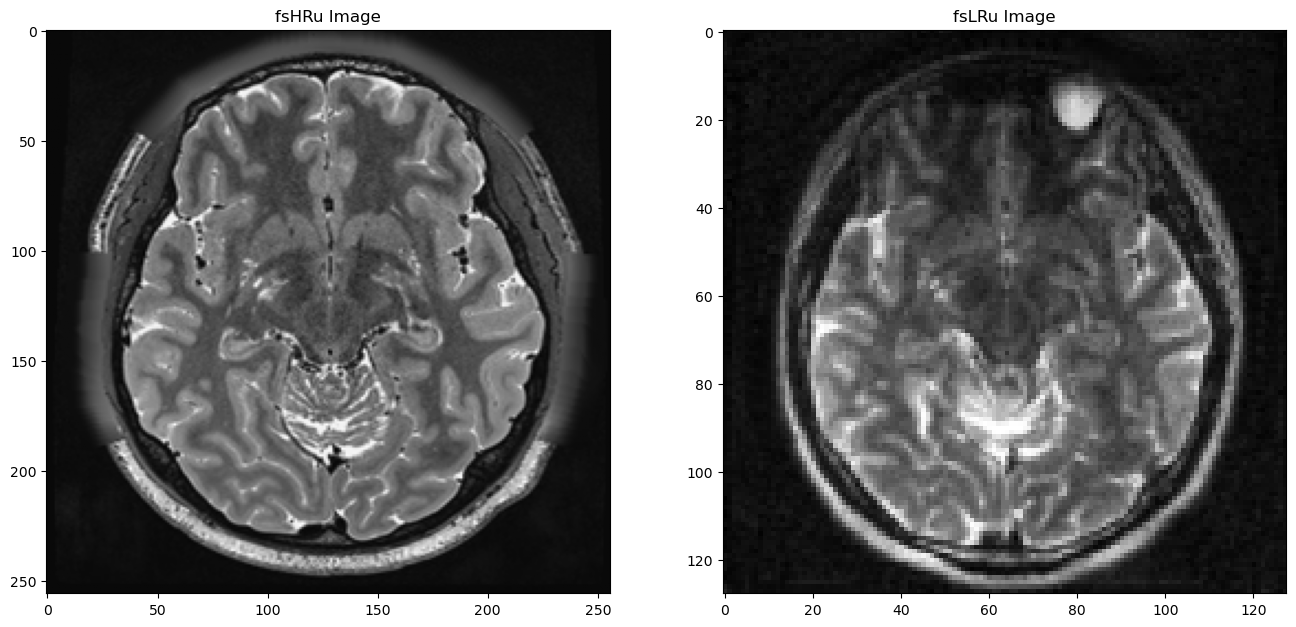

In [84]:
# # Uncomment for visualization if you stored all preprocessed data 
# Select a sample from the fully sampled image domain & print dimensions
sample_fsGdtimgP = Gdt_imagesP[0]; sample_fsImgimgP = Img_imagesP[0]
print(f"Dimensions of - fsHRimgP: {sample_fsGdtimgP.shape}, fsLRimgP: {sample_fsImgimgP.shape}")

sample_fsGdtimgU = Gdt_imagesU[0]; sample_fsImgimgU = Img_imagesU[0]
print(f"Dimensions of - fsHRimgU: {sample_fsGdtimgU.shape}, fsLRimgU: {sample_fsImgimgU.shape}")

# Compute minVal, maxVal, SSIM & PSNR
print(f"\nminVal of LR: {sample_fsImgimgU.min()}, maxVal of LR: {sample_fsImgimgU.max()}")
print(f"minVal of HR: {sample_fsGdtimgU.min()}, maxVal of HR: {sample_fsGdtimgU.max()}")

# Plot unpatched images for LR & HR
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1); plt.imshow(sample_fsGdtimgU, cmap='gray'); plt.title("fsHRu Image")
plt.subplot(1, 2, 2); plt.imshow(sample_fsImgimgU, cmap='gray'); plt.title("fsLRu Image")
plt.show()

# Plot patched images for LR & HR
# plt.figure(figsize=(16, 8))
# plt.subplot(1, 2, 1); plt.imshow(sample_fsGdtimgP[10,10], cmap='gray'); plt.title("fsHRp Image")
# plt.subplot(1, 2, 2); plt.imshow(sample_fsImgimgP[10,10], cmap='gray'); plt.title("fsLRp Image")
# plt.show()

__________________________

# Making Predictions on Testing Data

PyTorch

In [85]:
# Holdout Cross-Validation
model = MRI_SRDD(scale=2, n_atoms=64, in_channels=1).to(device)
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

MRI_SRDD(
  (dict_gen): Dictionary(
    (conv_1_1): PatchConv(
      (body): Sequential(
        (0): Conv2d(4, 4, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(4, 4, kernel_size=(1, 1), stride=(1, 1))
      )
      (act): ReLU(inplace=True)
    )
    (conv_1_2): PatchConv(
      (body): Sequential(
        (0): Conv2d(4, 4, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(4, 4, kernel_size=(1, 1), stride=(1, 1))
      )
      (act): ReLU(inplace=True)
    )
    (conv_2_1): PatchConv(
      (body): Sequential(
        (0): Conv2d(4, 4, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(4, 4, kernel_size=(1, 1), stride=(1, 1))
      )
      (act): ReLU(inplace=True)
    )
    (conv_2_2): PatchConv(
      (body): Sequential(
        (0): Conv2d(4, 4, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(4, 4, kernel_size=(1, 1), stride=(1, 1)

# QUALITATIVE RESULTS

In [86]:
from pathlib import Path

Path("outputs/npy").mkdir(parents=True, exist_ok=True)
Path("outputs/png").mkdir(parents=True, exist_ok=True)

for img_file, gdt_file in tqdm(zip(ts_df["imgFiles"], ts_df["gdtFiles"]), total=len(ts_df), desc="Processing Test Images"):

    Gdtimage = np.load(gdt_file)
    Imgimage = np.load(img_file)

    assert Gdtimage.shape[0] == Imgimage.shape[0] * 2
    assert Gdtimage.shape[1] == Imgimage.shape[1] * 2
    
    Imgimage = (Imgimage / 255) 
    Gdtimage = (Gdtimage / 255)
    
    lr_input = Imgimage.astype(np.float32)

    X_tst = torch.tensor(lr_input, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        pred, _, _ = model(X_tst)

    SRimage = pred.squeeze(0).squeeze(0).cpu().numpy()

    stem = Path(img_file).stem

    plt.imsave(f"outputs/png/{stem}.png", SRimage, cmap="gray")
    np.save(f"outputs/npy/{stem}.npy", SRimage)

Processing Test Images: 100%|██████████| 370/370 [00:27<00:00, 13.26it/s]


# QUANTITATIVE RESULTS

In [87]:
# Containers for metrics
ssimList = []; psnrList = []; records = []

# Test loop
for img_file, gdt_file in tqdm(zip(ts_df["imgFiles"], ts_df["gdtFiles"]), total=len(ts_df), desc="Processing Test Images"):
    
    # Load LR and HR images
    Gdtimage = np.load(gdt_file)   # HR image, expected shape: (512, 512)
    Imgimage = np.load(img_file)   # LR image, expected shape: (256, 256)

    # Sanity check
    assert Gdtimage.shape[0] == Imgimage.shape[0] * 2, f"Shape mismatch: HR {Gdtimage.shape}, LR {Imgimage.shape}"
    assert Gdtimage.shape[1] == Imgimage.shape[1] * 2, f"Shape mismatch: HR {Gdtimage.shape}, LR {Imgimage.shape}"

    # Normalize
    Imgimage = (Imgimage / 255) 
    Gdtimage = (Gdtimage / 255)

    # Convert LR image to tensor: (H, W) -> (1, 1, H, W)
    X_tst = torch.tensor(Imgimage, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        pred, _, _ = model(X_tst)

    # Convert prediction back to numpy
    SRimage = pred.squeeze(0).squeeze(0).cpu().numpy()

    # Optional: clip to valid range
    SRimage = np.clip(SRimage, 0.0, 1.0)

    # Compute metrics
    ssimSR = ssim(Gdtimage, SRimage, data_range=1.0)
    psnrSR = psnr(Gdtimage, SRimage, data_range=1.0)

    # # Compute metrics
    # ssimSR = ssim(np.abs(Gdtimage), np.abs(SRimage), data_range=np.abs(SRimage).ptp()) 
    # psnrSR = psnr(np.abs(Gdtimage), np.abs(SRimage), data_range=np.abs(SRimage).ptp())

    # Store metrics
    ssimList.append(ssimSR)
    psnrList.append(psnrSR)
    records.append({"img_file": img_file, "gdt_file": gdt_file, "SSIM": ssimSR, "PSNR": psnrSR})

# Per-image results
df_all = pd.DataFrame(records)

# Summary results
results_df = pd.DataFrame({"Metric": ["SSIM", "PSNR"], "Mean": [np.mean(ssimList), np.mean(psnrList)], "Std": [np.std(ssimList), np.std(psnrList)]})

print("\nSummary metrics:")
results_df.head()

Processing Test Images: 100%|██████████| 370/370 [00:22<00:00, 16.44it/s]


Summary metrics:


,Metric,Mean,Std
0,SSIM,0.937520,0.008355
1,PSNR,51.117166,0.520293


In [88]:
print("\nPer-image metrics:")
df_all.head()


Per-image metrics:


,img_file,gdt_file,SSIM,PSNR
0,G:\LF-7T-CycleGAN\pytorch-cyclegan-and-pix2pix...,G:\LF-7T-CycleGAN\pytorch-cyclegan-and-pix2pix...,0.952503,52.118330
1,G:\LF-7T-CycleGAN\pytorch-cyclegan-and-pix2pix...,G:\LF-7T-CycleGAN\pytorch-cyclegan-and-pix2pix...,0.948384,51.837913
2,G:\LF-7T-CycleGAN\pytorch-cyclegan-and-pix2pix...,G:\LF-7T-CycleGAN\pytorch-cyclegan-and-pix2pix...,0.945892,51.654360
3,G:\LF-7T-CycleGAN\pytorch-cyclegan-and-pix2pix...,G:\LF-7T-CycleGAN\pytorch-cyclegan-and-pix2pix...,0.945291,51.586472
4,G:\LF-7T-CycleGAN\pytorch-cyclegan-and-pix2pix...,G:\LF-7T-CycleGAN\pytorch-cyclegan-and-pix2pix...,0.943881,51.483689


# **APPENDIX**